<a href="https://colab.research.google.com/github/al7272-byte/Methane-Hydrate-ANN-PINN/blob/main/ANN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
from google.colab import drive

drive.mount('/content/drive')

file_path = '/content/drive/MyDrive/ML Grp Project /Association_PINN/data cleaning.xlsx'
df = pd.read_excel(file_path)

print(df.head())


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
   Pressure (bar)  Bulk Temperature (Tb) (K)  \
0              30                     273.65   
1              30                     273.15   
2              30                     272.65   
3              30                     272.15   
4              30                     271.65   

   Phase boundary temperature (Teq) (K)  Methane Mean Concentration (mol/m3)  \
0                            275.882601                                  746   
1                            276.523588                                  747   
2                            277.406043                                  749   
3                            278.348631                                  751   
4                            279.288247                                  752   

    Delta T  Propogation Rate (m/s)  Updated Propogation Rate  \
0  2.232601                0.000003 

In [ ]:


import matplotlib.pyplot as plt
import numpy as np

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split  # For splitting the data
from sklearn.preprocessing import StandardScaler  # For feature scaling
from sklearn.metrics import mean_squared_error, r2_score  # For MSE and R^2 calculations

# Assuming 'df' contains the columns 'Pressure (bar)', 'Bulk Temperature (Tb) (K)',
# 'Methane Mean Concentration (mol/m3)', and 'Propagation Distance'

# Prepare the data
X = df[['Pressure (bar)', 'Bulk Temperature (Tb) (K)', 'Methane Mean Concentration (mol/m3)','Sub-cooling temperature(K)']]  # Input features
y = df['Propogation Distance']  # Target variable (ensure correct column name)

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5, random_state=42)

# Normalize the input features
scaler = StandardScaler()  # Initialize the scaler
X_train = scaler.fit_transform(X_train)  # Fit and transform the training data
X_test = scaler.transform(X_test)  # Transform the test data using the same scaler

# Create the ANN model
model_1_plain = keras.Sequential([
    layers.Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    layers.Dense(32, activation='relu'),
    layers.Dense(1)  # Single neuron for regression output
])

# Compile the model
model_1_plain.compile(optimizer='adam', loss='mse', metrics=['mae'])  # Use Mean Squared Error as the loss

# Train the model
model_1_plain.fit(X_train, y_train, epochs=100, batch_size=32, validation_split=0.2)

# Evaluate the model
loss, mae = model_1_plain.evaluate(X_test, y_test)
print(f"Mean Squared Error: {loss:.2f}")
print(f"Mean Absolute Error: {mae:.2f}")

# Make predictions
y_pred = model_1_plain.predict(X_test)

# Calculate R^2 Score
r2 = r2_score(y_test, y_pred)
print(f"R^2 Score: {r2:.2f}")


Epoch 1/100


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - loss: 28.3766 - mae: 4.1803 - val_loss: 14.3533 - val_mae: 2.4379
Epoch 2/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step - loss: 27.8411 - mae: 4.1270 - val_loss: 14.0419 - val_mae: 2.4125
Epoch 3/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step - loss: 27.3141 - mae: 4.0746 - val_loss: 13.7384 - val_mae: 2.3872
Epoch 4/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 146ms/step - loss: 26.7957 - mae: 4.0244 - val_loss: 13.4388 - val_mae: 2.3620
Epoch 5/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 129ms/step - loss: 26.2796 - mae: 3.9779 - val_loss: 13.1408 - val_mae: 2.3388
Epoch 6/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 144ms/step - loss: 25.7622 - mae: 3.9311 - val_loss: 12.8470 - val_mae: 2.3316
Epoch 7/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step - loss: 25.2476 - mae: 3.8839 - val_loss: 12.5473 - val_mae: 2.3231
Epoch 8/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 137ms/step - loss: 24.7374 - mae: 3.8364 - val_loss: 12.2446 - val_mae: 2.3140
Epoch 9/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step - loss: 24.2279 

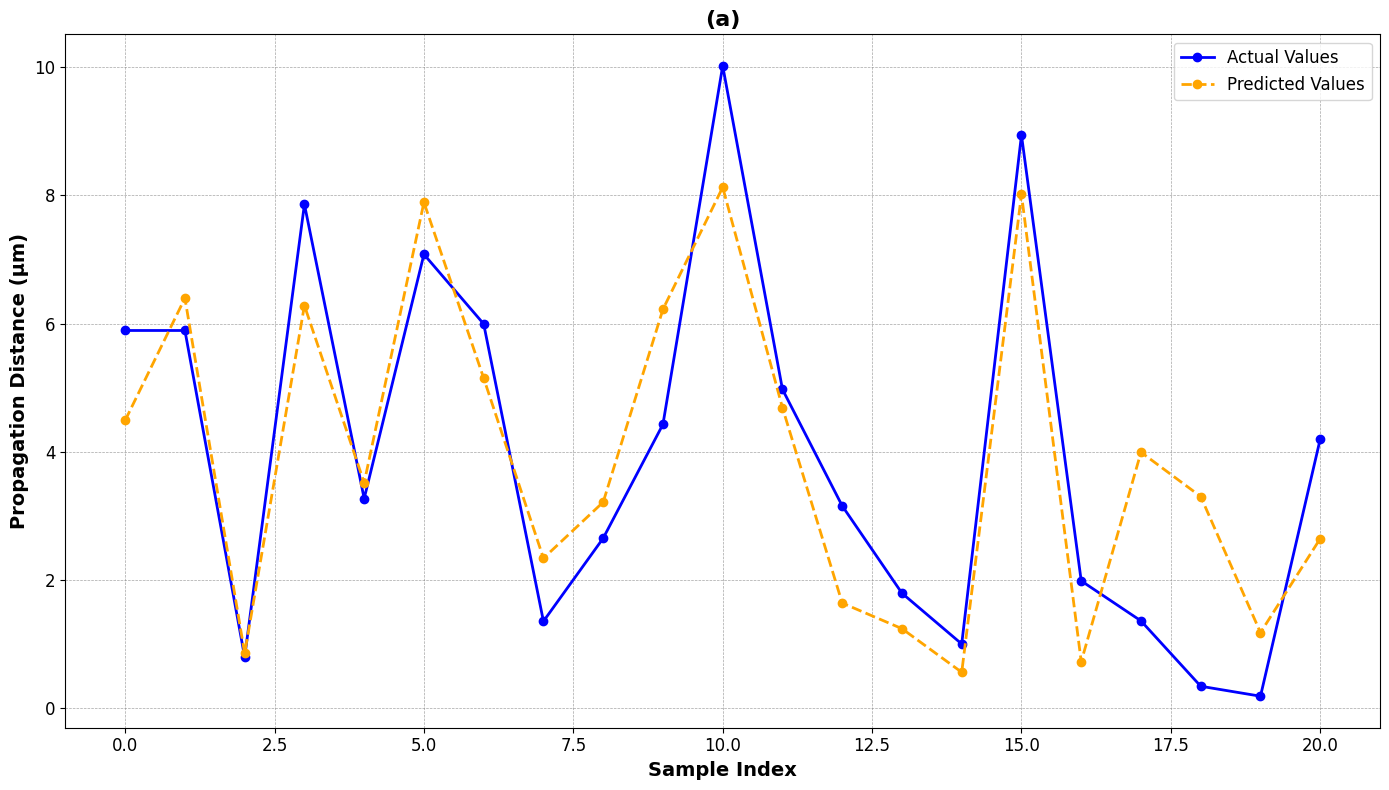

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Plot Actual vs Predicted values over samples
plt.figure(figsize=(14, 8))
plt.plot(np.arange(len(y_test)), y_test, color='blue', marker='o', linewidth=2, label='Actual Values')
plt.plot(np.arange(len(y_test)), y_pred, color='orange', marker='o', linestyle='--', linewidth=2, label='Predicted Values')

# Customizing the plot
plt.xlabel('Sample Index', fontsize=14, fontweight='bold')
plt.ylabel('Propagation Distance (µm)', fontsize=14, fontweight='bold')
plt.title('(a)', fontsize=16, fontweight='bold')
plt.legend(fontsize=12)
plt.grid(color='gray', linestyle='--', linewidth=0.5, alpha=0.7)

# Enhance ticks
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

# Save the plot (optional)
# plt.savefig('sequential_comparison.png', dpi=300, bbox_inches='tight')

# Show the plot
plt.tight_layout()
plt.show()

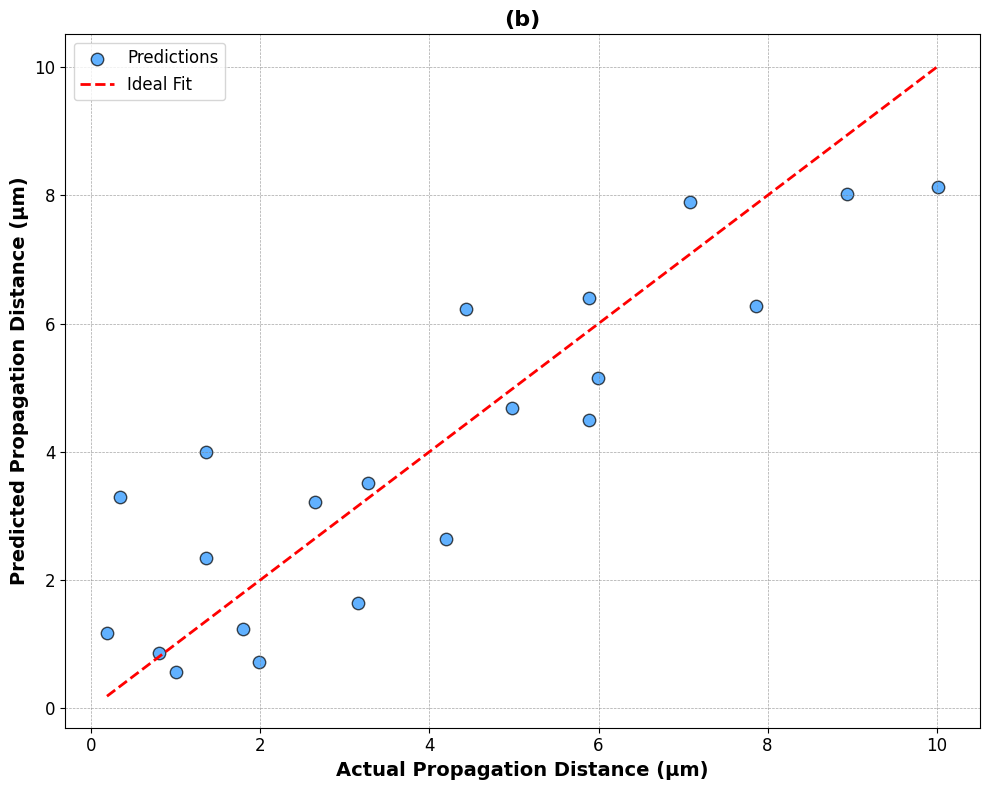

In [ ]:
# Scatter plot: Actual vs Predicted
plt.figure(figsize=(10, 8))
plt.scatter(y_test, y_pred, alpha=0.7, edgecolor='black', s=80, color='dodgerblue', label='Predictions')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linestyle='--', linewidth=2, label='Ideal Fit')

# Customizing the plot
plt.xlabel('Actual Propagation Distance (µm)', fontsize=14, fontweight='bold')
plt.ylabel('Predicted Propagation Distance (µm)', fontsize=14, fontweight='bold')
plt.title('(b)', fontsize=16, fontweight='bold')
plt.legend(fontsize=12)
plt.grid(color='gray', linestyle='--', linewidth=0.5, alpha=0.7)

# Enhance ticks
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

# Save the plot (optional)
# plt.savefig('actual_vs_predicted_scatter.png', dpi=300, bbox_inches='tight')

# Show the plot
plt.tight_layout()
plt.show()


In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split, KFold
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# Assuming 'df' contains the columns 'Pressure (bar)', 'Bulk Temperature (Tb) (K)',
# 'Methane Mean Concentration (mol/m3)', and 'Updated Propagation Rate'

# Prepare the data (fixing the column name typo)
X = df[['Pressure (bar)', 'Bulk Temperature (Tb) (K)', 'Methane Mean Concentration (mol/m3)','Sub-cooling temperature(K)']]  # Input features
y = df['Propogation Distance']  # Target variable (ensure correct column name)

# Polynomial Features for non-linear relationships (optional, adjust degree if needed)
poly = PolynomialFeatures(degree=2)
X_poly = poly.fit_transform(X)

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_poly, y, test_size=0.5, random_state=42)

# Normalize the input features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Normalize the target variable (if needed)
y_scaler = StandardScaler()
y_train = y_scaler.fit_transform(y_train.values.reshape(-1, 1))
y_test = y_scaler.transform(y_test.values.reshape(-1, 1))

# Create a more complex ANN model with dropout regularization
model = keras.Sequential([
    layers.Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
    layers.Dropout(0.2),  # Dropout layer to reduce overfitting
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.2),  # Additional dropout layer
    layers.Dense(32, activation='relu'),
    layers.Dense(1)  # Output layer for regression
])

# Compile the model with a lower learning rate and Nadam optimizer
optimizer = keras.optimizers.Nadam(learning_rate=0.001)
model.compile(optimizer=optimizer, loss='mse', metrics=['mae'])

# Implement early stopping to avoid overfitting
#early_stopping = keras.callbacks.EarlyStopping(patience=10, restore_best_weights=True)

# Train the model with validation and early stopping
model.fit(X_train, y_train, epochs=100, batch_size=32, validation_split=0.2)

# Evaluate the model on the test set
loss, mae = model.evaluate(X_test, y_test)
print(f"Mean Squared Error (MSE): {loss:.2f}")
print(f"Mean Absolute Error (MAE): {mae:.2f}")

# Make predictions
y_pred = model.predict(X_test)

# Inverse transform the predicted and actual target variable for comparison
y_pred = y_scaler.inverse_transform(y_pred)
y_test_inv = y_scaler.inverse_transform(y_test)

# Additional evaluation metrics
#mse = mean_squared_error(y_test_inv, y_pred)
#mae = mean_absolute_error(y_test_inv, y_pred)
r2 = r2_score(y_test_inv, y_pred)

print(f"R-Squared (R2 Score): {r2:.2f}")

# Optional: Implement k-fold cross-validation for more robust evaluation



Epoch 1/100


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step - loss: 1.1467 - mae: 0.8811 - val_loss: 1.1428 - val_mae: 0.9684
Epoch 2/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 174ms/step - loss: 0.8481 - mae: 0.7311 - val_loss: 1.0708 - val_mae: 0.9447
Epoch 3/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 298ms/step - loss: 0.8517 - mae: 0.7158 - val_loss: 1.0031 - val_mae: 0.9179
Epoch 4/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 144ms/step - loss: 0.8026 - mae: 0.7266 - val_loss: 0.9433 - val_mae: 0.8962
Epoch 5/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 167ms/step - loss: 0.6801 - mae: 0.6736 - val_loss: 0.8865 - val_mae: 0.8741
Epoch 6/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step - loss: 0.4664 - mae: 0.5253 - val_loss: 0.8434 - val_mae: 0.8621
Epoch 7/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step - loss: 0.4466 - mae: 0.5639 - val_loss: 0.7716 - val_mae: 0.8282
Epoch 8/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 139ms/step - loss: 0.4172 - mae: 0.5030 - val_loss: 0.7096 - val_mae: 0.7948
Epoch 9/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 182ms/step - loss: 0.3198 - mae: 0.4460 -

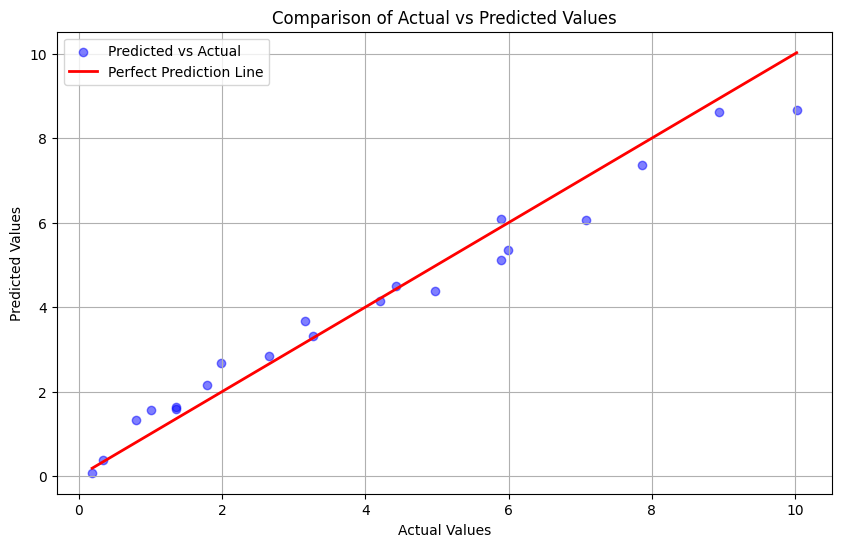

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Assuming y_test_inv (inverse transformed y_test) and y_pred (predicted values) are already computed

# Create a scatter plot for comparison
plt.figure(figsize=(10, 6))
plt.scatter(y_test_inv, y_pred, color='blue', label='Predicted vs Actual', alpha=0.5)
plt.plot([min(y_test_inv), max(y_test_inv)], [min(y_test_inv), max(y_test_inv)], color='red', lw=2, label='Perfect Prediction Line')

# Label the axes
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Comparison of Actual vs Predicted Values')
plt.legend()
plt.grid(True)

# Show the plot
plt.show()


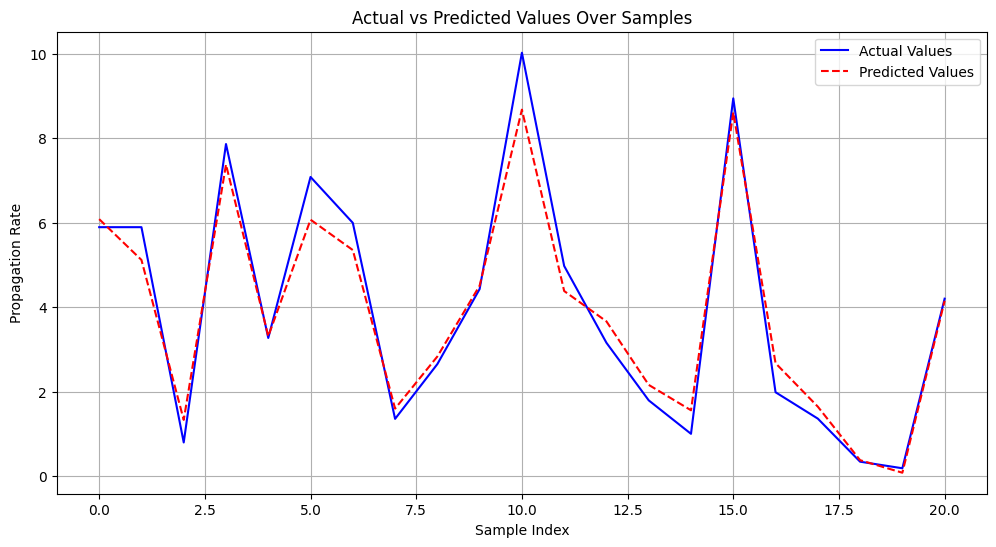

In [ ]:
# Plot for sequential comparison (good for time series data or ordered data)
plt.figure(figsize=(12, 6))
plt.plot(np.arange(len(y_test_inv)), y_test_inv, color='blue', label='Actual Values')
plt.plot(np.arange(len(y_test_inv)), y_pred, color='red', linestyle='--', label='Predicted Values')

# Label the axes
plt.xlabel('Sample Index')
plt.ylabel('Propagation Rate')
plt.title('Actual vs Predicted Values Over Samples')
plt.legend()
plt.grid(True)

# Show the plot
plt.show()
